In [9]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [12]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

In [13]:
export_hwannier("wannier");
export_heph("wannier");
export_momentum("wannier");

In [14]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");
Pwannier = pwannier("wannier");

In [15]:
lattice_vectors=loadlattice("totalE.out")

3-element Vector{Vector{Float64}}:
 [2.764420648, 0.0, 0.0]
 [-1.382210324, 2.39406024924, 0.0]
 [0.0, 0.0, 15.87531]

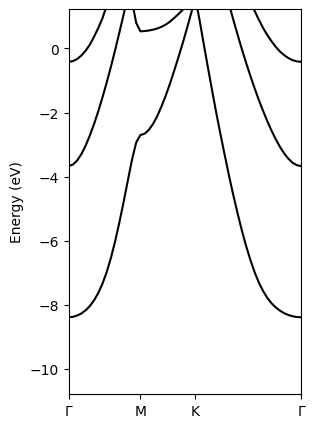

PyObject Text(23.999999999999993, 0.5, 'Energy (eV)')

In [18]:
figure(figsize=(3, 5))
plot_bands(Hwannier, cell_map, kpointsfile="../../bandstruct.kpoints", color="black", whichbands=[6, 7, 8])
label_plots("../../bandstruct.kpoints.in", "../../bandstruct.kpoints")
ylim(-6-4.78, 6-4.78)
ylabel("Energy (eV)")

In [19]:
subsampling = returnfermikpoint(Hwannier, cell_map, -4.78, Val(2), mesh=20, num_blocks=1000, histogram_width=1)

(Real[0.3903564280906149 0.21997917028572744 … 0.9604416203235406 0.3790598650140933; 0.905354900592769 0.5751170720766758 … 0.386824039866716 0.9564524553840739; 0.0 0.0 … 0.0 0.0], 0.11400249999999999)

In [24]:
tau = τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -4.78, supplydos=0.11, mesh=20, num_blocks=30, histogram_width=1, supplysampling=subsampling)

DOS at Fermi Energy is: 0.11
Sampling from 45601kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30


100-element Vector{Float64}:
 114.3417988033352
 114.18114579689296
 113.92468092432446
 113.58764888091855
 113.18843355400472
 112.7464297936421
 112.28017201758837
 111.80596865082524
 111.33712496371463
 110.88370055233605
 110.4526690828087
 110.04832604637441
 109.67280779693715
   ⋮
 104.78329567237594
 104.77380297314723
 104.76452056819308
 104.75544154601272
 104.74655929469324
 104.73786748585061
 104.72936005959396
 104.72103121043538
 104.71287537407815
 104.70488721502075
 104.69706161491621
 104.68939366163589

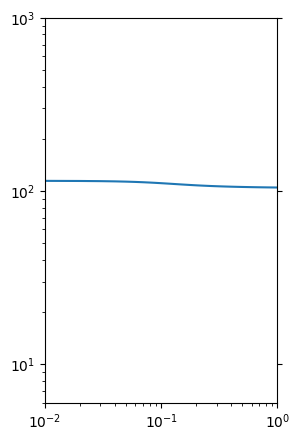

(0.01, 1)

In [26]:
figure(figsize=(3, 5))
loglog(collect(0.01:0.01:1), tau)
tick_params(right = true)

ylim(6, 1000)
xlim(1e-2, 1)

In [82]:
np.savetxt("argentene_tau.txt", tau)

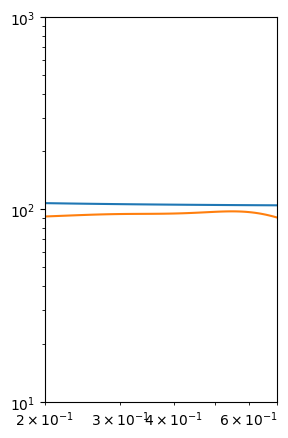

(0.2, 0.7)

In [98]:
figure(figsize=(3,5))
loglog(collect(0.2:0.01:0.7),  np.loadtxt("argentene_tau.txt")[20:70])
loglog(collect(0.2:0.01:0.7),  smooth(tau_allen[20:70], win_len=30))


ylim(10, 1e3)
xlim(0.2, 0.7)


In [55]:
# Now we compare against the true high frequency result
tau_allen =  JJDFTX.τ_allen(Hwannier, cell_map, Pwannier, force_matrix, cellph_map, Heph, celleph_map,
    collect(0.01:0.01:1),  -4.78, Val(2); 
mesh=3, supplydos=0.11, num_blocks=1000, fracroom=1, histogram_width=1)

DOS at Fermi Energy is: 0.11
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98


Block: 753
Block: 754
Block: 755
Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843

100-element Vector{Float64}:
 28.283210364228296
 44.77665846075634
 55.43171174058564
 58.31325202013871
 62.559556040719166
 67.87319557695157
 71.83436030857263
 74.47736112222617
 76.06350651344961
 79.1739247729083
 79.61653351358801
 82.36874464222028
 86.08745678858523
  ⋮
 58.823963140031275
 58.56735441879027
 57.56249459789413
 55.13875782902664
 52.87849584260136
 51.593663389268585
 49.91916118518955
 49.1702318990758
 48.48993785397876
 47.384025908772806
 46.36132639025348
 45.611899670422595

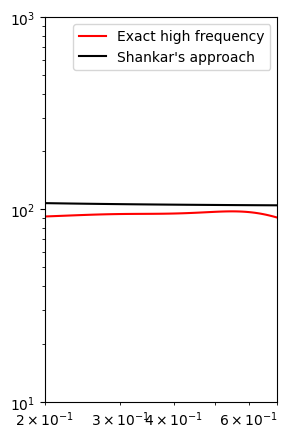

PyObject <matplotlib.legend.Legend object at 0x7f1adb295100>

In [81]:
figure(figsize=(3, 5))
lower = 20
upper = 70
loglog(collect(0.01:0.01:1)[lower:upper], smooth(tau_allen[lower:upper], win_len=30), color="red", label="Exact high frequency")
loglog(collect(0.01:0.01:1)[lower:upper], tau[lower:upper], color="black", label="Shankar's approach")
ylim(10, 1000)
xlim(0.20, 0.70)
legend()

In [30]:
phbands = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../../bandstruct.kpoints");

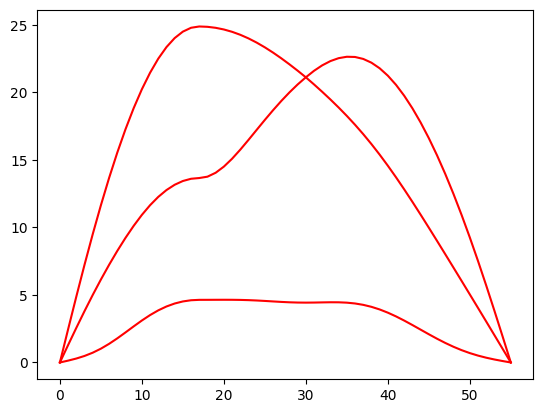

3-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f1ae53471f0>
 PyObject <matplotlib.lines.Line2D object at 0x7f1ae53472e0>
 PyObject <matplotlib.lines.Line2D object at 0x7f1ae53473a0>

In [31]:
plot(phbands*1e3, color="red")